In [29]:
import torch
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device("cuda")

In [4]:
SEED = 42
TEST_SIZE = 0.2
N_SAMPLES = 500_000
TYPES = torch.float16

In [5]:
X, y = make_circles(N_SAMPLES, random_state=SEED, noise=0.05, factor=0.3)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    shuffle=True,
    stratify=y,
    random_state=SEED,
    test_size=TEST_SIZE
)

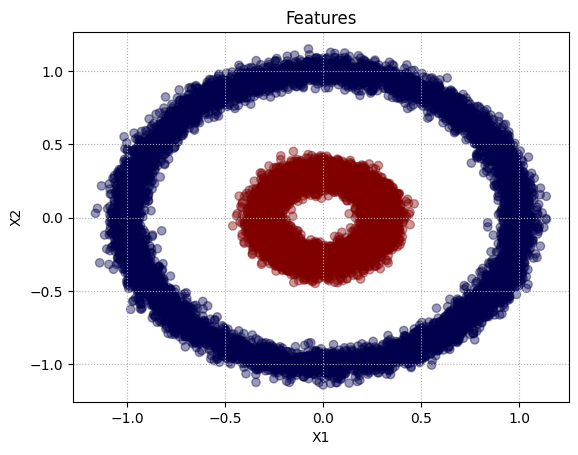

In [7]:
SAMPLE = 15_000
fig, ax = plt.subplots()
ax.scatter(
    X_train[:SAMPLE, 0],
    X_train[:SAMPLE, 1],
    c=y_train[:SAMPLE],
    alpha=0.4,
    cmap='seismic'
)
ax.grid(True, linestyle=':')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title('Features')
plt.show()

In [11]:
X_train, X_test = torch.tensor(X_train, dtype=TYPES), torch.tensor(X_test, dtype=TYPES)
y_train, y_test = torch.tensor(y_train, dtype=TYPES).unsqueeze(1), torch.tensor(y_test, dtype=TYPES).unsqueeze(1)

In [13]:
W1 = torch.nn.Parameter(torch.randn(2, 8, dtype=TYPES) * 0.1)
b1 = torch.nn.Parameter(torch.zeros(8, dtype=TYPES))

In [14]:
W2 = torch.nn.Parameter(torch.randn(8, 8, dtype=TYPES) * 0.1)
b2 = torch.nn.Parameter(torch.zeros(8, dtype=TYPES))

In [15]:
W3 = torch.nn.Parameter(torch.randn(8, 1, dtype=TYPES) * 0.1)
b3 = torch.nn.Parameter(torch.zeros(1, dtype=TYPES))

In [16]:
def forward(x):

    z1 = x @ W1 + b1
    a1 = torch.relu(z1)

    z2 = a1 @ W2 + b2
    a2 = torch.relu(z2)

    out = a2 @ W3 + b3

    return out

In [17]:
def mse(pred, target):

    return ((pred - target) ** 2).mean()

In [21]:
((torch.relu(torch.relu(X_train @ W1 + b1) @ W2 + b2) @ W3) + b3)

tensor([[-5.6171e-04],
        [ 3.1519e-04],
        [-6.4075e-05],
        ...,
        [-1.0133e-06],
        [-1.9896e-04],
        [ 3.0422e-04]], device='cuda:0', dtype=torch.float16,
       grad_fn=<AddBackward0>)

In [19]:
y_train

tensor([[0.],
        [1.],
        [0.],
        ...,
        [0.],
        [1.],
        [1.]], device='cuda:0', dtype=torch.float16)

In [22]:
((torch.relu(torch.relu(X_train @ W1 + b1) @ W2 + b2) @ W3) + b3) - y_train

tensor([[-5.6171e-04],
        [-9.9951e-01],
        [-6.4075e-05],
        ...,
        [-1.0133e-06],
        [-1.0000e+00],
        [-9.9951e-01]], device='cuda:0', dtype=torch.float16,
       grad_fn=<SubBackward0>)

In [52]:
LR = 1e-2

In [59]:
epochs = 500

params = [W1, b1, W2, b2, W3, b3]

for epoch in range(epochs):

    # Forward
    pred = forward(X_train)

    # Loss
    loss = F.binary_cross_entropy_with_logits(pred, y_train)

    # Backpropagation
    loss.backward()

    # Atualização manual dos pesos
    with torch.no_grad():

        for p in params:
            p -= LR * p.grad

    # Zerar gradientes
    for p in params:
        p.grad.zero_()

    if epoch % 50 == 0:

        print(
            f"Epoch {epoch:3d} | Loss = {loss.item():.6f}"
        )

Epoch   0 | Loss = 0.018631
Epoch  50 | Loss = 0.018631
Epoch 100 | Loss = 0.018631
Epoch 150 | Loss = 0.018631
Epoch 200 | Loss = 0.018631
Epoch 250 | Loss = 0.018631
Epoch 300 | Loss = 0.018631
Epoch 350 | Loss = 0.018631
Epoch 400 | Loss = 0.018631
Epoch 450 | Loss = 0.018631


In [56]:
torch.sigmoid(pred)

tensor([[0.0176],
        [0.9839],
        [0.0429],
        ...,
        [0.0101],
        [0.9819],
        [0.9893]], device='cuda:0', dtype=torch.float16,
       grad_fn=<SigmoidBackward0>)

In [49]:
y_train

tensor([[0.],
        [1.],
        [0.],
        ...,
        [0.],
        [1.],
        [1.]], device='cuda:0', dtype=torch.float16)

In [50]:
W1

Parameter containing:
tensor([[-0.2698,  1.5303,  0.1992, -1.4229,  0.0559,  0.7139, -0.5127, -0.0680],
        [ 0.5000, -0.8213, -0.1033, -0.5117,  0.0164,  0.3809, -1.0322,  1.7217]],
       device='cuda:0', dtype=torch.float16, requires_grad=True)

In [73]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_layer = nn.Linear(1, 1, bias=False)
        self.hidden_layer = nn.Linear(1, 1, bias=False)
        self.output_layer = nn.Linear(1, 1, bias=False)

    def forward(self, x):
        x = torch.relu(self.input_layer(x))
        x = torch.relu(self.hidden_layer(x))
        x = self.output_layer(x)
        return x

In [74]:
model = Net()

In [75]:
model

Net(
  (input_layer): Linear(in_features=1, out_features=1, bias=False)
  (hidden_layer): Linear(in_features=1, out_features=1, bias=False)
  (output_layer): Linear(in_features=1, out_features=1, bias=False)
)

In [76]:
for i in model.parameters():
    print(i)

Parameter containing:
tensor([[0.9279]], device='cuda:0', requires_grad=True)
Parameter containing:
tensor([[-0.0453]], device='cuda:0', requires_grad=True)
Parameter containing:
tensor([[-0.4704]], device='cuda:0', requires_grad=True)
